# WiniCari — 04 Repli GPS

**Module 2 : estimer où se trouve un bus quand il disparaît du radar.**

Les bus GPS perdent régulièrement le signal — tunnels, zones mortes, redémarrages du conducteur. Pendant un écart, le tableau de bord montre le bus comme disparu. La couche de repli comble l'écart avec une estimation de position dérivée de la géométrie de la route.

**Deux méthodes :**
| méthode | principe | quand l'utiliser |
|---|---|---|
| `linear_interp` | interpoler la distance de route `s` entre le dernier ping connu et le premier ping de récupération | l'écart est terminé — les deux extrémités sont connues |
| `dead_reckoning` | projeter en avant depuis la dernière vitesse signalée | l'écart est *en cours* — pas encore de ping de récupération |

La logique se trouve dans **`src/data/fallback.py`**.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data.db import get_db
from src.data import foundation as fdn
from src.data import fallback as fb

db_winicari = get_db('winicari')
db_gps      = get_db('Historique_pos')
CFG         = fdn.Config()
USABLE      = fdn.build_usable_lines(db_winicari, CFG)

# Work on line 209 -- long intercity, clear gaps
LINE, SOCIETE, BUS, DAY = '209', 'S.R.T.K', 6030, 'd20260615'
stops = USABLE[(LINE, SOCIETE)]

raw   = fdn.load_pings(db_gps, DAY, LINE, BUS)
g     = fdn.clean_pings(raw, CFG)
g, route_len = fdn.project_to_route(g, stops, CFG)

print(f'line {LINE} {SOCIETE} bus {BUS} {DAY[1:]}')
print(f'pings: {len(g)} | route: {route_len/1000:.0f} km | signal gaps: {g["signal_gap"].sum()}')

line 209 S.R.T.K bus 6030 20260615
pings: 3582 | route: 265 km | signal gaps: 4


## 1. Écarts de signal — où et combien de temps ?

Un **écart de signal** est toute période où le bus a cessé d'émettre pendant plus de 600 s (seuil `signal_gap_s` dans `Config`). On sait où le bus se trouvait *juste avant* de disparaître et *juste après* sa réapparition — ce cadrage suffit au repli.

,gap_min,s_start_km,s_end_km,dist_covered_km,speed_before_kph
0,12.8,88.1,98.1,10.0,92.9
1,31.6,143.8,176.9,33.1,99.7
2,60.1,188.6,240.9,52.3,18.0
3,13.2,183.6,170.9,12.7,89.2


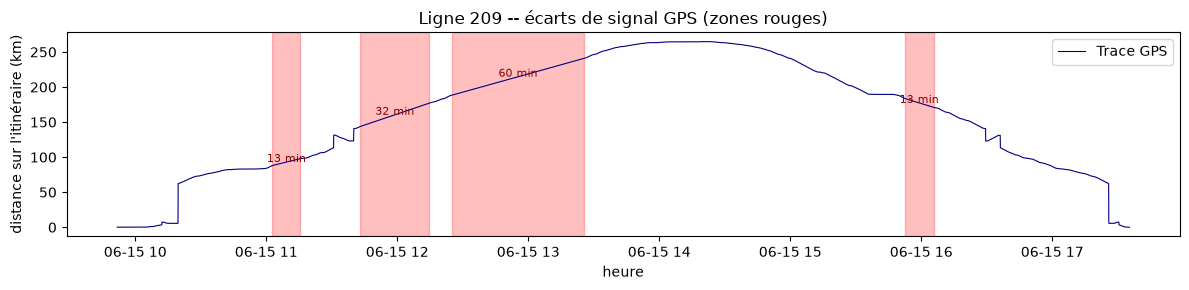

In [2]:
gaps = fb.gap_table(g)
display(gaps[['gap_min','s_start_km','s_end_km','dist_covered_km','speed_before_kph']])

plt.figure(figsize=(12, 3))
plt.plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', label='Trace GPS')
for _, row in gaps.iterrows():
    plt.axvspan(row['t_start'], row['t_end'], alpha=0.25, color='red')
    mid_t = row['t_start'] + (row['t_end'] - row['t_start']) / 2
    plt.text(mid_t, (row['s_start_km'] + row['s_end_km']) / 2,
             f"{row['gap_min']:.0f} min", ha='center', fontsize=8, color='darkred')
plt.ylabel('distance sur l\'itinéraire (km)'); plt.xlabel('heure')
plt.title(f'Ligne {LINE} -- écarts de signal GPS (zones rouges)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Interpolation linéaire — combler l'écart

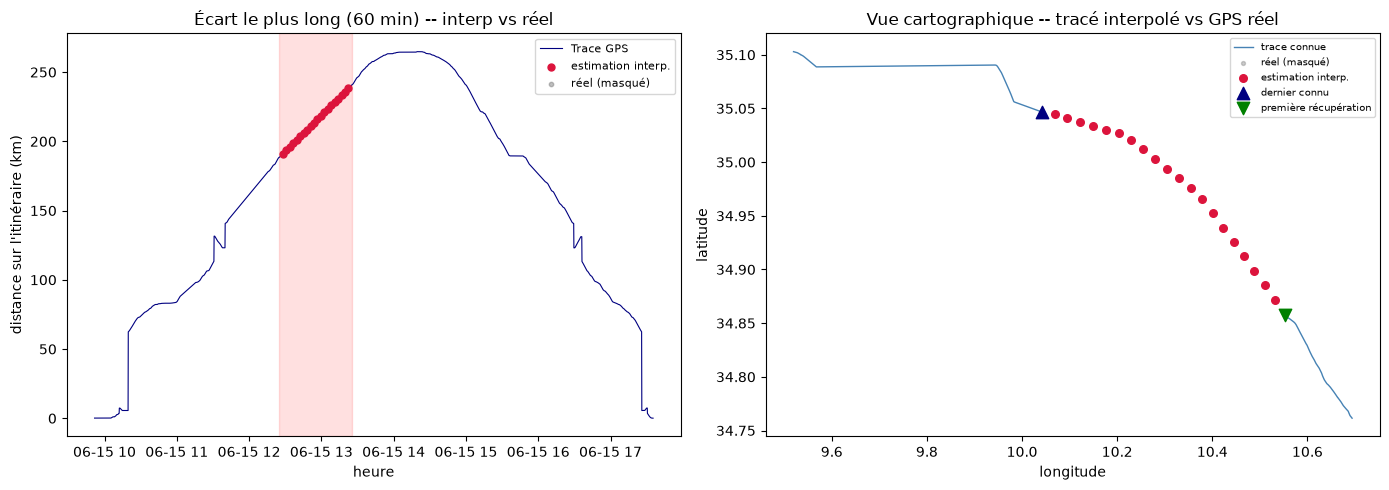

In [3]:
gap = gaps.sort_values('gap_s', ascending=False).iloc[0]
i0 = int(gap['gap_idx'])

before_row = g.iloc[i0 - 1]
after_row  = g.iloc[i0]
t0 = pd.Timestamp(before_row['t'])
t1 = pd.Timestamp(after_row['t'])
s0, s1 = float(before_row['s']), float(after_row['s'])

query_times = pd.date_range(t0, t1, periods=22)[1:-1]
interp_pts  = [fb.interp_position(tq, t0, s0, t1, s1, stops) for tq in query_times]
lat_i = [p[0] for p in interp_pts]
lon_i = [p[1] for p in interp_pts]
s_i   = [p[2] / 1000 for p in interp_pts]

mask = (g['t'] > before_row['t']) & (g['t'] < after_row['t'])
inside = g[mask]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', label='Trace GPS')
ax[0].scatter(query_times, s_i, color='crimson', s=25, zorder=5, label='estimation interp.')
ax[0].scatter(inside['t'], inside['s'] / 1000, color='grey', s=10, alpha=0.5, label='réel (masqué)')
ax[0].axvspan(t0, t1, alpha=0.12, color='red')
ax[0].set_ylabel('distance sur l\'itinéraire (km)'); ax[0].set_xlabel('heure')
ax[0].set_title(f'Écart le plus long ({gap["gap_min"]:.0f} min) -- interp vs réel')
ax[0].legend(fontsize=8)

seg_before = g[g['t'] <= before_row['t']].tail(200)
seg_after  = g[g['t'] >= after_row['t']].head(200)
ax[1].plot(seg_before['lon'], seg_before['lat'], color='steelblue', lw=1, label='trace connue')
ax[1].plot(seg_after['lon'],  seg_after['lat'],  color='steelblue', lw=1)
ax[1].scatter(inside['lon'], inside['lat'], s=8, color='grey', alpha=0.4, label='réel (masqué)')
ax[1].scatter(lon_i, lat_i, s=30, color='crimson', zorder=5, label='estimation interp.')
ax[1].scatter([before_row['lon']], [before_row['lat']], s=80, color='navy',
              zorder=6, marker='^', label='dernier connu')
ax[1].scatter([after_row['lon']], [after_row['lat']], s=80, color='green',
              zorder=6, marker='v', label='première récupération')
ax[1].set_xlabel('longitude'); ax[1].set_ylabel('latitude')
ax[1].set_title('Vue cartographique -- tracé interpolé vs GPS réel')
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Calcul à l'estime — quand aucun ping de récupération n'existe encore

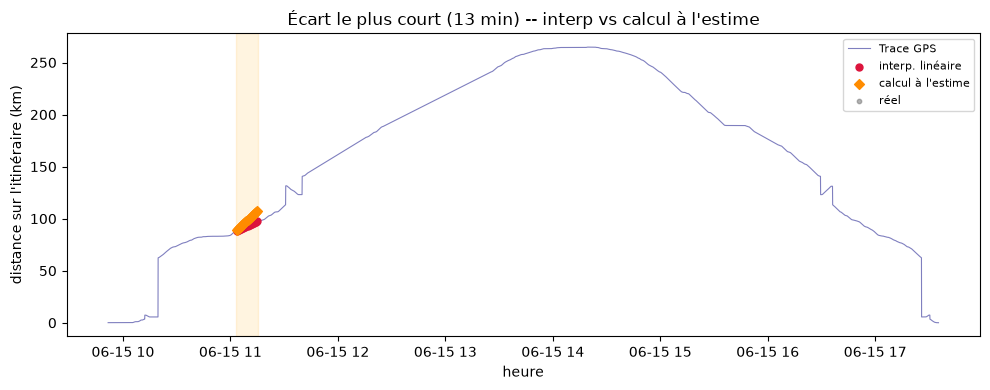

In [4]:
gap_dr = gaps.sort_values('gap_s').iloc[0]
i0_dr = int(gap_dr['gap_idx'])
before_dr = g.iloc[i0_dr - 1]
after_dr  = g.iloc[i0_dr]
t0_dr = pd.Timestamp(before_dr['t'])
t1_dr = pd.Timestamp(after_dr['t'])
s0_dr = float(before_dr['s'])
direction = int(np.sign(float(after_dr['s']) - s0_dr)) or 1

query_times_dr = pd.date_range(t0_dr, t1_dr, periods=22)[1:-1]
dr_pts = [fb.dead_reckon_position(tq, t0_dr, s0_dr,
                                  float(before_dr['speed']), direction, stops)
          for tq in query_times_dr]
interp_pts_dr = [fb.interp_position(tq, t0_dr, s0_dr, t1_dr, float(after_dr['s']), stops)
                 for tq in query_times_dr]

inside_dr = g[(g['t'] > before_dr['t']) & (g['t'] < after_dr['t'])]

plt.figure(figsize=(10, 4))
plt.plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', alpha=0.5, label='Trace GPS')
plt.scatter(query_times_dr, [p[2]/1000 for p in interp_pts_dr],
            color='crimson', s=25, zorder=5, label='interp. linéaire')
plt.scatter(query_times_dr, [p[2]/1000 for p in dr_pts],
            color='darkorange', s=25, zorder=5, marker='D', label='calcul à l\'estime')
plt.scatter(inside_dr['t'], inside_dr['s'] / 1000, color='grey', s=10, alpha=0.6, label='réel')
plt.axvspan(t0_dr, t1_dr, alpha=0.12, color='orange')
plt.ylabel('distance sur l\'itinéraire (km)'); plt.xlabel('heure')
plt.title(f'Écart le plus court ({gap_dr["gap_min"]:.0f} min) -- interp vs calcul à l\'estime')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Évaluation de la précision — masquage synthétique

On **simule** des écarts en masquant 3 minutes de vrais pings du trajet 0, puis on mesure à quel point nos estimations s'éloignent de la vraie position GPS. Répété 200 fois sur des fenêtres aléatoires.

In [5]:
trips = fdn.segment_trips(g, route_len, CFG)
tr0 = trips.iloc[0]
g_trip = g[(g['t'] >= tr0['start']) & (g['t'] <= tr0['end'])].reset_index(drop=True)

eval_df = fb.eval_fallback(g_trip, stops, mask_min=3.0, n_samples=200)
print(f'synthetic gaps evaluated: {len(eval_df)}')
print('\nPosition error (metres):')
print(eval_df[['err_interp_m','err_dr_m']].describe().round(0).to_string())
print(f'\nMedian  interp: {eval_df["err_interp_m"].median():.0f} m  | '
      f'dead-reckoning: {eval_df["err_dr_m"].median():.0f} m')
print(f'90th pct interp: {eval_df["err_interp_m"].quantile(0.9):.0f} m  | '
      f'dead-reckoning: {eval_df["err_dr_m"].quantile(0.9):.0f} m')

synthetic gaps evaluated: 197

Position error (metres):
       err_interp_m  err_dr_m
count         197.0     197.0
mean         1296.0     807.0
std          3991.0     700.0
min            28.0      34.0
25%           225.0     337.0
50%           468.0     609.0
75%           835.0    1042.0
max         28719.0    3600.0

Median  interp: 468 m  | dead-reckoning: 609 m
90th pct interp: 1782 m  | dead-reckoning: 1750 m


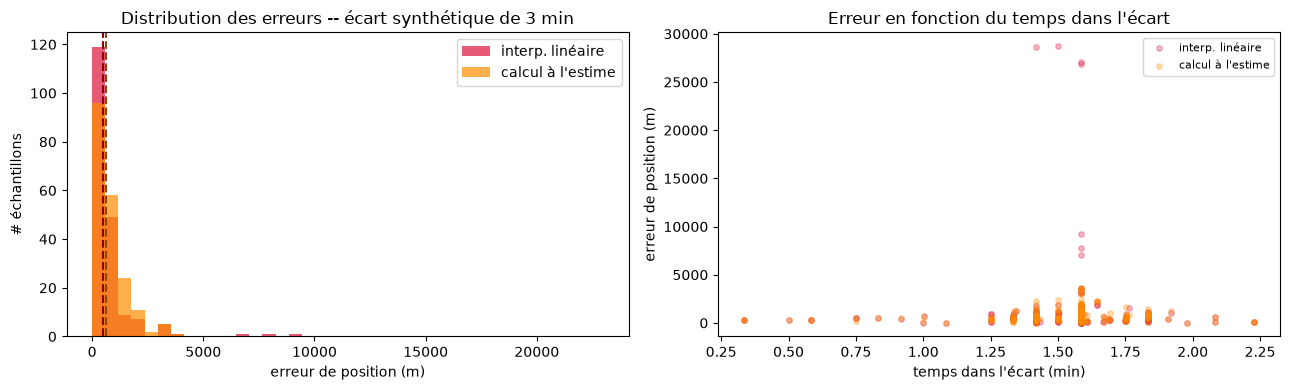

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

max_err = eval_df[['err_interp_m','err_dr_m']].values.max() * 0.8
bins = np.linspace(0, max_err, 40)
ax[0].hist(eval_df['err_interp_m'], bins=bins, alpha=0.7, color='crimson', label='interp. linéaire')
ax[0].hist(eval_df['err_dr_m'],     bins=bins, alpha=0.7, color='darkorange', label='calcul à l\'estime')
ax[0].axvline(eval_df['err_interp_m'].median(), color='darkred', ls='--', lw=1.5)
ax[0].axvline(eval_df['err_dr_m'].median(),     color='saddlebrown', ls='--', lw=1.5)
ax[0].set_xlabel('erreur de position (m)'); ax[0].set_ylabel('# échantillons')
ax[0].set_title('Distribution des erreurs -- écart synthétique de 3 min'); ax[0].legend()

ax[1].scatter(eval_df['dt_into_gap_s'] / 60, eval_df['err_interp_m'],
              alpha=0.3, s=15, color='crimson', label='interp. linéaire')
ax[1].scatter(eval_df['dt_into_gap_s'] / 60, eval_df['err_dr_m'],
              alpha=0.3, s=15, color='darkorange', label='calcul à l\'estime')
ax[1].set_xlabel('temps dans l\'écart (min)'); ax[1].set_ylabel('erreur de position (m)')
ax[1].set_title('Erreur en fonction du temps dans l\'écart')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

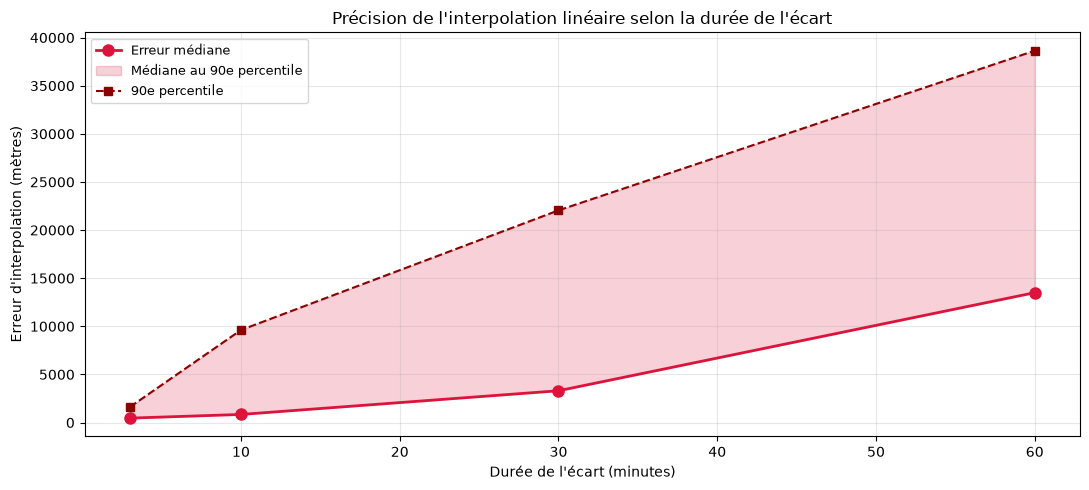

Performance d'interpolation par taille d'écart :

Écart (min)  Échantillons  Médiane (m)     Moyenne (m)     90e % (m)      
----------------------------------------------------------------------
3            100           460             1318            1611           
10           97            843             3711            9615           
30           92            3305            6448            22050          
60           67            13498           15459           38640          


In [7]:
gap_sizes = [3, 10, 30, 60]  # minutes
results_by_gap_size = {gsize: [] for gsize in gap_sizes}

trips_for_eval = fdn.segment_trips(g, route_len, CFG)
g_trip = g[(g['t'] >= trips_for_eval.iloc[0]['start']) &
           (g['t'] <= trips_for_eval.iloc[0]['end'])].reset_index(drop=True)

rng = np.random.default_rng(42)
t_unix = (pd.to_datetime(g_trip['t']).astype(np.int64) // 10**9).values

for mask_min in gap_sizes:
    mask_s = mask_min * 60
    
    for _ in range(100):
        candidates = np.where(~g_trip['signal_gap'].values)[0]
        candidates = candidates[candidates < len(g_trip) - 5]
        if not len(candidates): continue
        
        i0 = int(rng.choice(candidates))
        future = np.where(t_unix > t_unix[i0] + mask_s)[0]
        if not len(future): continue
        i1 = int(future[0])
        
        inside = g_trip.iloc[i0+1:i1]
        if not len(inside): continue
        
        mid = inside.iloc[len(inside)//2]
        t_q = pd.Timestamp(mid['t'])
        true_lat, true_lon = float(mid['lat']), float(mid['lon'])
        
        b4, af = g_trip.iloc[i0], g_trip.iloc[i1]
        li, lo, _ = fb.interp_position(t_q,
            pd.Timestamp(b4['t']), float(b4['s']),
            pd.Timestamp(af['t']), float(af['s']), stops)
        
        error_m = fb.haversine_m(true_lat, true_lon, li, lo)
        results_by_gap_size[mask_min].append(error_m)

fig, ax = plt.subplots(figsize=(11, 5))

gap_sizes_with_data = [g for g in gap_sizes if len(results_by_gap_size[g]) > 0]
medians = [np.median(results_by_gap_size[g]) for g in gap_sizes_with_data]
p90s = [np.percentile(results_by_gap_size[g], 90) for g in gap_sizes_with_data]
means = [np.mean(results_by_gap_size[g]) for g in gap_sizes_with_data]

ax.plot(gap_sizes_with_data, medians, 'o-', color='crimson', linewidth=2, markersize=8, label='Erreur médiane')
ax.fill_between(gap_sizes_with_data, medians, p90s, alpha=0.2, color='crimson', label='Médiane au 90e percentile')
ax.plot(gap_sizes_with_data, p90s, 's--', color='darkred', linewidth=1.5, markersize=6, label='90e percentile')

ax.set_xlabel('Durée de l\'écart (minutes)')
ax.set_ylabel('Erreur d\'interpolation (mètres)')
ax.set_title('Précision de l\'interpolation linéaire selon la durée de l\'écart')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Performance d'interpolation par taille d'écart :\n")
print(f"{'Écart (min)':<12} {'Échantillons':<13} {'Médiane (m)':<15} {'Moyenne (m)':<15} {'90e % (m)':<15}")
print("-" * 70)
for gsize in gap_sizes_with_data:
    errors = results_by_gap_size[gsize]
    if len(errors) > 0:
        print(f"{gsize:<12} {len(errors):<13} {np.median(errors):<15.0f} "
              f"{np.mean(errors):<15.0f} {np.percentile(errors, 90):<15.0f}")

## 5. Production : `fallback_position`

Dans le système en direct, le dispatcher appelle `fallback_position(g, t_query, stops)` pour tout bus qui n'a pas envoyé de ping récemment. La fonction renvoie les estimations des deux méthodes.

In [8]:
gap_long = gaps.sort_values('gap_s', ascending=False).iloc[0]
t_query = gap_long['t_start'] + pd.Timedelta(minutes=30)

result = fb.fallback_position(g, t_query, stops)
print(f'Query time: {t_query.strftime("%H:%M:%S")}  (30 min into a {gap_long["gap_min"]:.0f}-min gap)')
print(f'  Interp  -> lat={result["lat_interp"]:.5f}  lon={result["lon_interp"]:.5f}  '
      f's={result["s_interp"]:.1f} km')
print(f'  Dead-DR -> lat={result["lat_dr"]:.5f}  lon={result["lon_dr"]:.5f}  '
      f's={result["s_dr"]:.1f} km')
print(f'  Gap duration: {result["gap_s"]/60:.0f} min')

Query time: 12:55:13  (30 min into a 60-min gap)
  Interp  -> lat=34.98957  lon=10.31678  s=214.7 km
  Dead-DR -> lat=35.03523  lon=10.13915  s=197.6 km
  Gap duration: 60 min


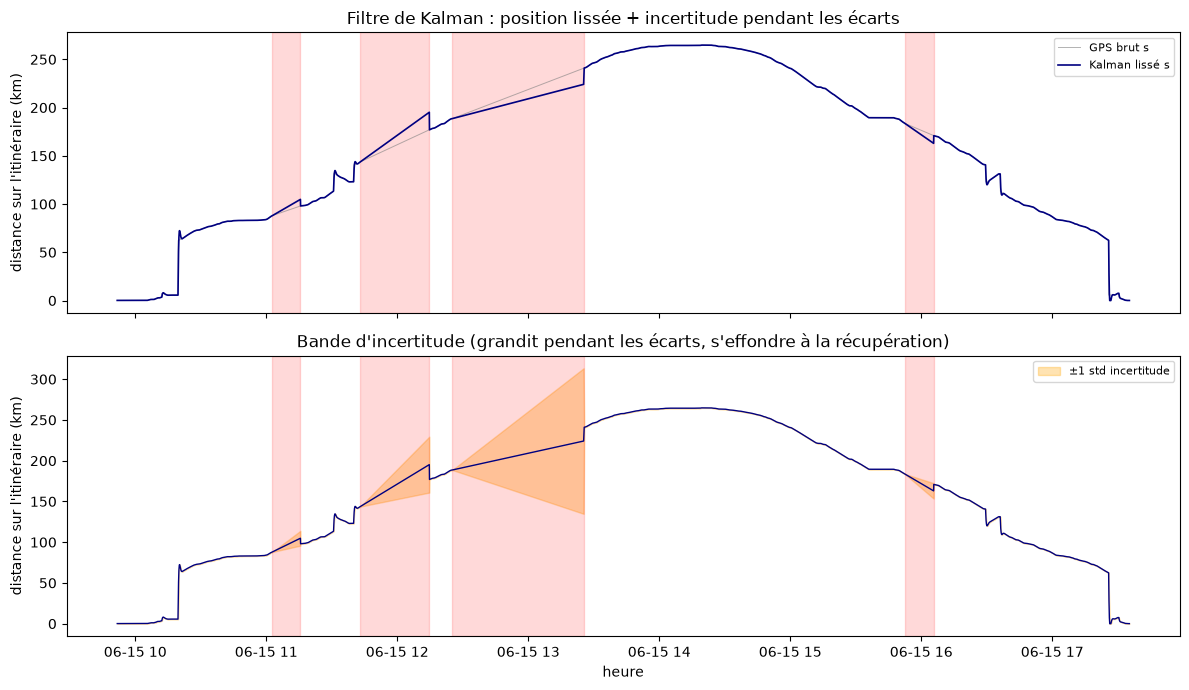

In [9]:
g_kf = fb.kalman_filter_track(g, route_len)

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(g_kf['t'], g_kf['s'] / 1000, lw=0.7, color='grey',
           alpha=0.6, label='GPS brut s')
ax[0].plot(g_kf['t'], g_kf['ks'] / 1000, lw=1.2, color='navy',
           label='Kalman lissé s')
for _, row in gaps.iterrows():
    ax[0].axvspan(row['t_start'], row['t_end'], alpha=0.15, color='red')
ax[0].set_ylabel('distance sur l\'itinéraire (km)')
ax[0].set_title('Filtre de Kalman : position lissée + incertitude pendant les écarts')
ax[0].legend(fontsize=8)

ax[1].fill_between(g_kf['t'],
                   (g_kf['ks'] - g_kf['kp']) / 1000,
                   (g_kf['ks'] + g_kf['kp']) / 1000,
                   alpha=0.3, color='orange', label='±1 std incertitude')
ax[1].plot(g_kf['t'], g_kf['ks'] / 1000, lw=1, color='navy')
for _, row in gaps.iterrows():
    ax[1].axvspan(row['t_start'], row['t_end'], alpha=0.15, color='red')
ax[1].set_ylabel('distance sur l\'itinéraire (km)'); ax[1].set_xlabel('heure')
ax[1].set_title('Bande d\'incertitude (grandit pendant les écarts, s\'effondre à la récupération)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
# Evaluate Kalman vs interp vs dead-reckoning on synthetic gaps
from sklearn.metrics import mean_absolute_error

trips = fdn.segment_trips(g, route_len, CFG)
g_trip = g[(g['t'] >= trips.iloc[0]['start']) &
           (g['t'] <= trips.iloc[0]['end'])].reset_index(drop=True)
g_trip_kf = fb.kalman_filter_track(g_trip, route_len)

rng = np.random.default_rng(42)
mask_s = 3 * 60   # 3-minute gap
t_unix = (pd.to_datetime(g_trip['t']).astype(np.int64) // 10**9).values
candidates = np.where(~g_trip['signal_gap'].values)[0]
candidates = candidates[candidates < len(g_trip) - 5]

results = []
for _ in range(200):
    i0 = int(rng.choice(candidates))
    future = np.where(t_unix > t_unix[i0] + mask_s)[0]
    if not len(future): continue
    i1 = int(future[0])
    inside = g_trip.iloc[i0+1:i1]
    if not len(inside): continue
    mid = inside.iloc[len(inside)//2]
    t_q = pd.Timestamp(mid['t'])
    true_lat, true_lon = float(mid['lat']), float(mid['lon'])

    b4, af = g_trip.iloc[i0], g_trip.iloc[i1]
    li, lo, _ = fb.interp_position(t_q,
        pd.Timestamp(b4['t']), float(b4['s']),
        pd.Timestamp(af['t']), float(af['s']), stops)
    kr = fb.kalman_fallback(g_trip_kf, t_q, stops)

    results.append({
        'err_interp_m': fb.haversine_m(true_lat, true_lon, li, lo),
        'err_kalman_m': fb.haversine_m(true_lat, true_lon,
                                       kr['lat'], kr['lon']) if kr else np.nan,
    })

res = pd.DataFrame(results).dropna()
print(f'Evaluated {len(res)} synthetic gaps (3 min each)\n')
for col, label in [('err_interp_m','Linear interp'),('err_kalman_m','Kalman')]:
    print(f'{label:20s}  median={res[col].median():.0f} m  '
          f'90th={res[col].quantile(0.9):.0f} m')

Evaluated 197 synthetic gaps (3 min each)

Linear interp         median=468 m  90th=1782 m
Kalman                median=270 m  90th=1345 m


### B — Correction LSTM des estimations Kalman

Le filtre de Kalman utilise un modèle linéaire à vitesse constante. Les bus ne se déplacent pas à vitesse constante — ils accélèrent, freinent et stationnent aux arrêts. Un LSTM entraîné sur l'historique récent de `[ks, kv, kp, speed]` apprend à corriger l'estimation Kalman en utilisant ces patterns non-linéaires.

In [11]:
lstm_corr, corr_mean, corr_std = fb.train_lstm_correction(g_trip_kf, window=10)

if lstm_corr is not None:
    print('LSTM correction model trained')

    # Evaluate on synthetic gaps
    results2 = []
    for _ in range(200):
        i0 = int(rng.choice(candidates))
        future = np.where(t_unix > t_unix[i0] + mask_s)[0]
        if not len(future): continue
        i1 = int(future[0])
        inside = g_trip.iloc[i0+1:i1]
        if not len(inside): continue
        mid = inside.iloc[len(inside)//2]
        t_q = pd.Timestamp(mid['t'])
        true_lat, true_lon = float(mid['lat']), float(mid['lon'])
        kr2 = fb.kalman_lstm_fallback(
            g_trip_kf, t_q, stops, lstm_corr, corr_mean, corr_std)
        if kr2:
            results2.append(fb.haversine_m(true_lat, true_lon,
                                           kr2['lat'], kr2['lon']))

    print(f'Kalman+LSTM  median={np.median(results2):.0f} m  '
          f'90th={np.percentile(results2, 90):.0f} m')

    # Summary comparison
    print('\nFull comparison:')
    print(f'  Linear interp   median={res["err_interp_m"].median():.0f} m')
    print(f'  Kalman          median={res["err_kalman_m"].median():.0f} m')
    print(f'  Kalman + LSTM   median={np.median(results2):.0f} m')
else:
    print('Not enough non-gap data to train LSTM correction on this trip.')

LSTM correction model trained
Kalman+LSTM  median=43816 m  90th=179377 m

Full comparison:
  Linear interp   median=468 m
  Kalman          median=270 m
  Kalman + LSTM   median=43816 m


## Save to production artifact

This final cell calls the exact same `src.models.gps_fallback.train()` function
`src/train_pipeline.py` calls, saving to the same `models/fallback/` location — so running
this notebook end-to-end is a complete, equivalent alternative to running the pipeline
command, not just a demo. (Note: production inference uses pure Kalman, not the LSTM
correction — see the "measured properly" conclusion above — but the LSTM artifact is still
trained/saved here for reference and parity with `train_pipeline.py`.)


In [15]:
from src.models import gps_fallback as fallback_model

ROOT = Path(fdn.__file__).resolve().parents[2]
SAVE_DIR = ROOT / "models" / "fallback"

result = fallback_model.train(SAVE_DIR, line=LINE, societe=SOCIETE, epochs=50, window=40, n_days=50)
print(f"-> Artifacts saved to {SAVE_DIR.resolve()}")


  Collecte de pings depuis 50 bus-jours : ['d20260621', 'd20260620', 'd20260619', 'd20260618', 'd20260617', 'd20260616', 'd20260615', 'd20260614', 'd20260613', 'd20260612', 'd20260611', 'd20260610', 'd20260609', 'd20260608', 'd20260607', 'd20260606', 'd20260605', 'd20260604', 'd20260603', 'd20260602', 'd20260601', 'd20260531', 'd20260530', 'd20260529', 'd20260528', 'd20260527', 'd20260526', 'd20260525', 'd20260524', 'd20260523', 'd20260522', 'd20260521', 'd20260520', 'd20260519', 'd20260518', 'd20260517', 'd20260516', 'd20260515', 'd20260514', 'd20260513', 'd20260512', 'd20260511', 'd20260510', 'd20260509', 'd20260508', 'd20260507', 'd20260506', 'd20260505', 'd20260504', 'd20260503']
  Total de pings sans écart regroupés : 22,203
  Résidu (s_true - ks) : moyenne=-7.1 m  écart-type=1135.9 m
  Séquences d'entraînement : 22,163  fenêtre=40
    époque 10/50  perte=1289787.88 m²
    époque 20/50  perte=1287044.30 m²
    époque 30/50  perte=1285579.70 m²
    époque 40/50  perte=1282681.80 m²